In [46]:
from pathlib import Path

from lib.fs.get_script_name import get_name
from lib.fs.project_config import REPO_ROOT
from plotting import plot_config

script_name = get_name()
out_dir = REPO_ROOT / "figures" / script_name
out_dir.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import h5py

In [47]:
SUBJECT_ID = "sub-NDARINVAG388HJL"
FILE_SUFFIX = "_task-restAP_run-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.h5"

# FILE_DIR = Path("/cluster/work/ianpe/masters_thesis/bids_processed_consolidated_data") # IDUN
FILE_DIR = Path("/Users/ipeglin/Documents/masters_thesis/bids_processed_consolidated_data") # LOCAL
FILE_PATH = FILE_DIR / SUBJECT_ID / f"{SUBJECT_ID}{FILE_SUFFIX}"

ROIs = [21, 22, 23, 24, 25, 44, 45, 46, 47, 62, 93, 101, 221, 222, 223, 224, 225, 244, 245, 246, 247, 262, 293, 301, 402, 403, 418, 419] # randomly chosen

In [48]:
with h5py.File(FILE_PATH, 'r') as f:
  ds = f['01fmri_parcellation/full_run_std']
  ts = np.asarray(ds)

ROIs = ROIs if ROIs != [] else np.arange(0, ts.shape[0])  
roi_channels = ts[ROIs, :]

for i, r in enumerate(ROIs):
  np.testing.assert_array_equal(ts[r, :], roi_channels[i, :])

In [49]:
print(ts.shape)
print(roi_channels.shape)

(432, 488)
(28, 488)


In [50]:
num_bins = 224
bin_edges = np.linspace(roi_channels.min(), roi_channels.max(), num_bins)

# Right before the loop
print(f"DEBUG RANGE: min={roi_channels.min():.6f}, max={roi_channels.max():.6f}")
print(f"DEBUG SAMPLE: ROI 21, Time 0 raw value = {roi_channels[0, 0]:.6f}")

for i, c in enumerate(roi_channels):
  roi_idx = ROIs[i]
  num_time_steps = len(c)
  time = np.arange(num_time_steps)
  
  # bin_edges = np.linspace(c.min(), c.max(), num_bins)
  quantized_indices = np.digitize(c, bin_edges)
  # Convert to 0-based indices so they fit in our (0 to 223) array limits
  # Using np.clip ensures no out-of-bounds errors on extreme edges
  indices_0_based = np.clip(quantized_indices - 1, 0, num_bins - 1)
  
  quantized_data = bin_edges[np.minimum(quantized_indices, num_bins-1)]
  
  # Initialize the (224, 488) image array with 0.0
  image_2d = np.zeros((num_bins, num_time_steps))
  # Map the 1D values to a magnitude of 1.0 on the y-axis
  # Advanced indexing: image_2d[y_coordinates, x_coordinates] = 1.0
  image_2d[indices_0_based, np.arange(num_time_steps)] = 1.0
  locations = []
  for c in range(image_2d.shape[1]): # Time axis
      for r in range(image_2d.shape[0]): # Amplitude axis
          if image_2d[r, c] == 1.0:
              locations.append((c, r))
              break # Since it's one-hot, we can move to the next time step immediately

  print(f'Channel {roi_idx:03} — Sorted (time, amplitude):', locations[:20])

DEBUG RANGE: min=-3.445338, max=7.428955
DEBUG SAMPLE: ROI 21, Time 0 raw value = 5.322805
Channel 021 — Sorted (time, amplitude): [(0, 179), (1, 119), (2, 79), (3, 76), (4, 90), (5, 75), (6, 52), (7, 79), (8, 90), (9, 89), (10, 108), (11, 100), (12, 91), (13, 76), (14, 77), (15, 73), (16, 77), (17, 73), (18, 57), (19, 94)]
Channel 022 — Sorted (time, amplitude): [(0, 209), (1, 141), (2, 124), (3, 84), (4, 84), (5, 64), (6, 85), (7, 97), (8, 84), (9, 93), (10, 105), (11, 76), (12, 84), (13, 70), (14, 88), (15, 94), (16, 90), (17, 80), (18, 100), (19, 103)]
Channel 023 — Sorted (time, amplitude): [(0, 177), (1, 130), (2, 86), (3, 73), (4, 53), (5, 55), (6, 49), (7, 56), (8, 61), (9, 66), (10, 73), (11, 102), (12, 75), (13, 71), (14, 60), (15, 71), (16, 60), (17, 50), (18, 88), (19, 95)]
Channel 024 — Sorted (time, amplitude): [(0, 184), (1, 133), (2, 91), (3, 60), (4, 89), (5, 66), (6, 68), (7, 63), (8, 99), (9, 88), (10, 98), (11, 103), (12, 96), (13, 90), (14, 43), (15, 79), (16, 81),

ValueError: x and y must have same first dimension, but have shapes (488,) and (1,)

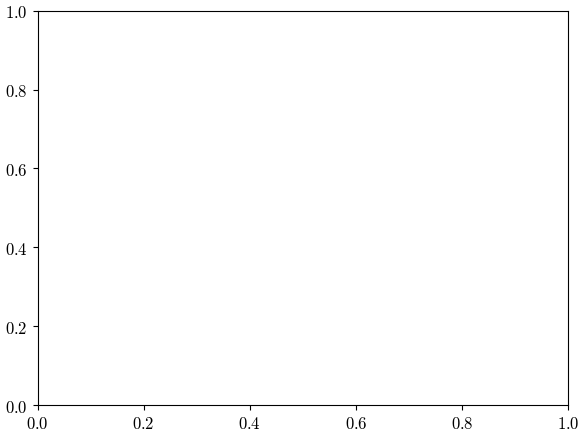

In [51]:
# 4. Plot original and quantized data
plt.figure(
  # figsize=(10, 6)
            )
plt.plot(time, c, 'k:', label='Original', alpha=0.5)
plt.plot(time, quantized_data, 'k-', label='Quantized (224 bins)', linewidth=1)
plt.legend()
plt.title(f'Time Series Quantization to 224 Bins (ROI {roi_idx})')
# plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
# Plot Original 1D Signal
ax1.plot(c, color='blue', linewidth=1.5)
ax1.set_title("Original 1D fMRI Signal")
ax1.set_ylabel("Amplitude")
ax1.grid(True, alpha=0.3)

# Plot 2D Image
# origin='lower' ensures row 0 (minimum amplitude) is rendered at the bottom
ax2.imshow(image_2d, aspect='auto', origin='lower', cmap='viridis')
ax2.set_title(f"2D Quantized Image Representation {image_2d.shape}")
ax2.set_xlabel("Time Steps")
ax2.set_ylabel("Quantization Bin (0-223)")